In [45]:
import pandas as pd
import numpy as np

In [46]:
df = pd.read_csv('fruits.csv')
df.head()

,Weight,Size,Class
0,69,4.39,orange
1,69,4.21,orange
2,65,4.09,orange
3,72,5.85,apple
4,67,4.70,orange


In [47]:
df.shape

(40, 3)

In [48]:
df.Class.value_counts() # Counting the datas from the dataset using the every classifications

Class
orange    20
apple     20
Name: count, dtype: int64

In [49]:
# data augumentation the number of data will be increased
# We need to reduce the disbalance of the class

In [50]:
df.isna().sum()

Weight    0
Size      0
Class     0
dtype: int64

In [51]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df['Class'] = le.fit_transform(df['Class'])
df.head()

,Weight,Size,Class
0,69,4.39,1
1,69,4.21,1
2,65,4.09,1
3,72,5.85,0
4,67,4.70,1


In [52]:
# Class 1 represents orange and class 0 is Apple
x = df.iloc[:,0:2]
y = df['Class']
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.1,random_state=1,shuffle=True, stratify=y) # Stratify is the equal number of apple and orange in the training dataset (removing class imbalance)

In [53]:
y_train.value_counts()

Class
0    18
1    18
Name: count, dtype: int64

# Naive Bayes Classification

In [54]:
from sklearn.naive_bayes import GaussianNB # Suited for structured data !! or BernaliNB , text -> MultinomialNB
nb = GaussianNB() # BernaulliNB or MultinomialNB
nb.fit(x_train,y_train)

GaussianNB()

In [55]:
# When x variable are also in o's and 1's then we need to use the BernoliNB (catrgorical data)
# Unstructured data is there we can use the -> MultinomialNB
# Structure data -> GaussianNB

# Evaluating the Model

In [56]:
nb.score(x_test, y_test) # simple to see the score of the model test dataset

1.0

In [57]:
nb.score(x_train,y_train) # simple to see the score of the model train dataset

1.0

In [58]:
y_pred = nb.predict(x_test)
from sklearn.metrics import confusion_matrix
print(confusion_matrix(y_test,y_pred))

[[2 0]
 [0 2]]


In [59]:
from sklearn.metrics import classification_report # For all the reports in confusion matrix
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00         2
           1       1.00      1.00      1.00         2

    accuracy                           1.00         4
   macro avg       1.00      1.00      1.00         4
weighted avg       1.00      1.00      1.00         4



In [60]:
nb.predict_proba(x_test)

array([[9.99630143e-01, 3.69856811e-04],
       [1.89205290e-08, 9.99999981e-01],
       [2.74172484e-04, 9.99725828e-01],
       [9.99999983e-01, 1.67865414e-08]])

In [61]:
nb.classes_

array([0, 1])

# Decision Tree

In [62]:
from sklearn.tree import DecisionTreeClassifier 

In [ ]:
dt = DecisionTreeClassifier() # Kart method -> classification as well as regression
dt.fit(x_train, y_train)

DecisionTreeClassifier()

In [64]:
# Explanable AI -> study it for your own good

In [65]:
dt.score(x_test, y_test)

1.0

In [66]:
dt.score(x_train, y_train)

1.0

[Text(0.5, 0.75, 'Size <= 4.93\ngini = 0.5\nsamples = 36\nvalue = [18, 18]'),
 Text(0.25, 0.25, 'gini = 0.0\nsamples = 18\nvalue = [0, 18]'),
 Text(0.375, 0.5, 'True  '),
 Text(0.75, 0.25, 'gini = 0.0\nsamples = 18\nvalue = [18, 0]'),
 Text(0.625, 0.5, '  False')]

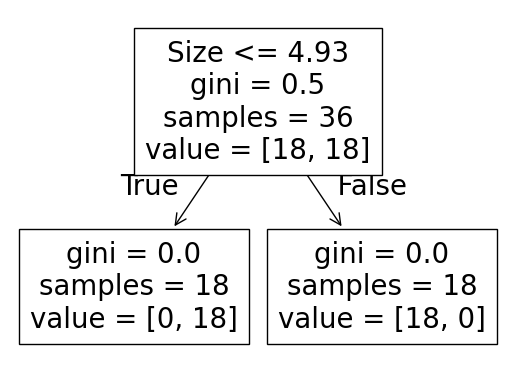

In [68]:
from sklearn.tree import plot_tree
plot_tree(dt, feature_names=["Weight","Size"])

In [71]:
from sklearn.tree import export_text
rules = export_text(dt, feature_names=["Weight","Size"])
print(rules)

|--- Size <= 4.93
|   |--- class: 1
|--- Size >  4.93
|   |--- class: 0

